## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.isotonic import IsotonicRegression
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import gaussian_filter1d
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Bibliothèques chargées")

Bibliothèques chargées


## Etape 1 : Préparation des données

On structure les données au niveau individuel pour estimer les hazards.

In [3]:
# Charger données
df = pd.read_csv("Export_ER_Agrege.csv", sep=";")

In [4]:
# --- NETTOYAGE / PREP HAZARD DISCRET ---

# 1) Filtre B_MAT + éviter les soucis de "view"
df = df[(df["B_MAT"] <= 170) | (df["B_MAT"].isna())].copy()

# 2) Drop variables dégénérées / inutiles
cols_to_drop = ["Unnamed: 19", "MREVAU", "MREVNU"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors="ignore")

# 3) DARRET (YYYYMM -> YYYY-MM-01)
df["DARRET"] = pd.to_datetime(df["DARRET"].astype(str) + "01",
                              format="%Y%m%d", errors="coerce")

# 4) EAD : harmonisation
if "E_EAD" in df.columns:
    df["EAD"] = df["E_EAD"]
    df = df.drop(columns=["E_EAD", "E_ONB"], errors="ignore")

# EAD obligatoire
df = df.dropna(subset=["EAD"])
# option: garder EAD >= 0
# df = df[df["EAD"] >= 0]

# 5) RA : NA -> 0 + contrainte RA >= 0
df["RA"] = df["RA"].fillna(0)
df = df[df["RA"] >= 0]

# 6) Typage catégories
for c in ["CLASSACT", "CSP", "produit"]:
    if c in df.columns:
        df[c] = df[c].astype("category")

# 7) Valeurs manquantes
if "Tx" in df.columns:
    # médiane par produit, sinon médiane globale
    if "produit" in df.columns:
        df["Tx"] = df.groupby("produit", observed=True)["Tx"].transform(lambda x: x.fillna(x.median()))
    df["Tx"] = df["Tx"].fillna(df["Tx"].median())

if "CSP" in df.columns:
    #df["CSP"] = df["CSP"].cat.add_categories("Inconnu")
    df["CSP"] = df["CSP"].fillna("Inconnu")

if "AGE_CLI" in df.columns:
    df["AGE_CLI"] = df["AGE_CLI"].fillna(df["AGE_CLI"].median())

if "MREVTOT" in df.columns:
    df["MREVTOT"] = df["MREVTOT"].fillna(df["MREVTOT"].median())

# 8) Produit : exclure "AR"
if "produit" in df.columns:
    df = df[df["produit"] != "AR"]

# 9) Tx : filtre "propre" (évite le 0.5 arbitraire)
# Si Tx est en décimal: 0.03 = 3%  => garder Tx > 0
# Si Tx est en %: 3 = 3%         => garder Tx > 0 aussi
if "Tx" in df.columns:
    df = df[df["Tx"] > 0]

# 10) Ages / horizons : IMPORTANT -> enlever NaN avant de calculer
# (sinon AGE_PRET et HORIZON_RES vont être NaN)
df = df.dropna(subset=["B_MAT", "B_RESMAT"])

df["AGE_PRET"] = df["B_MAT"] - df["B_RESMAT"]
df = df[(df["AGE_PRET"] >= 0) & (df["AGE_PRET"] <= df["B_MAT"])]

df["HORIZON_RES"] = df["B_RESMAT"].astype(int)

In [5]:
# Date origination en datetime
df["Date_origination"] = pd.to_datetime(df["Date_origination"], errors="coerce")

# (optionnel mais mieux) on enlève les lignes sans AGE_PRET ou FLAG_ER
df_recent = df.dropna(subset=["AGE_PRET", "FLAG_ER"]).copy()

# Sécurise le type
df_recent["AGE_PRET"] = df_recent["AGE_PRET"].astype(int)
df_recent["FLAG_ER"] = df_recent["FLAG_ER"].astype(int)  # 0/1

# Statistiques par âge (âge = mois depuis origination, ou ton AGE_PRET calculé)
age_stats = (
    df_recent.groupby("AGE_PRET", as_index=False)
    .agg(
        Taux_RA=("FLAG_ER", "mean"),
        Nb_RA=("FLAG_ER", "sum"),
        Nb_contrats=("FLAG_ER", "size"),
    )
)

print(f"\nÂges observés : {df_recent['AGE_PRET'].min()} à {df_recent['AGE_PRET'].max()} mois")
print(f"Âge moyen : {df_recent['AGE_PRET'].mean():.1f} mois")


Âges observés : 0 à 165 mois
Âge moyen : 26.6 mois


## Etape 2 : Estimation du hazard brut h(t)

### Définition

Le hazard $h(t)$ est la **probabilité de RA à l'âge $t$** pour les contrats qui ont survécu jusqu'à $t$ :

$$h(t) = P(\text{RA à } t | \text{Survie jusqu'à } t) = \frac{\text{Nb RA à } t}{\text{Nb contrats à risque à } t}$$

Dans nos données transversales (une observation par contrat), on approxime :

$$\hat{h}(t) \approx \frac{\text{Nb contrats avec FLAG_ER=1 à l'âge } t}{\text{Nb contrats observés à l'âge } t}$$

**Note** : C'est une approximation car on n'observe pas le processus longitudinal complet.

In [6]:
import numpy as np
import pandas as pd

MAX_AGE = 60
ID_COL = "ID"  # change si besoin

df_base = df.copy()

# temps
df_base["AGE_PRET"] = (df_base["B_MAT"] - df_base["B_RESMAT"]).astype(int)
df_base = df_base[(df_base["AGE_PRET"] >= 0) & (df_base["AGE_PRET"] <= df_base["B_MAT"])].copy()

# event (choisis UNE définition)
# si tu as RA montant :
df_base["EVENT"] = (df_base["RA"].fillna(0) > 0).astype(int)
# si tu préfères FLAG_ER :
# df_base["EVENT"] = df_base["FLAG_ER"].fillna(0).astype(int)

# IMPORTANT : on garde le vrai âge d’arrêt, sans clip
df_base["T_STOP_TRUE"] = df_base["AGE_PRET"].astype(int)

# on construit panel jusqu’à min(T_STOP_TRUE, MAX_AGE) mais sans transformer ça en event
df_base["T_STOP_PANEL"] = df_base["T_STOP_TRUE"].clip(lower=0, upper=MAX_AGE).astype(int)

panel = (
    df_base[[ID_COL, "EVENT", "T_STOP_TRUE", "T_STOP_PANEL"]]
    .dropna(subset=[ID_COL, "T_STOP_PANEL"])
    .assign(t=lambda d: d["T_STOP_PANEL"].map(lambda T: list(range(T + 1))))
    .explode("t", ignore_index=True)
)
panel["t"] = panel["t"].astype(int)

# y=1 seulement si event ET si l’event arrive AVANT OU EGAL à MAX_AGE
# (sinon c’est censuré à MAX_AGE)
panel["y"] = (
    (panel["EVENT"] == 1)
    & (panel["T_STOP_TRUE"] <= MAX_AGE)
    & (panel["t"] == panel["T_STOP_TRUE"])
).astype(int)

# hazard brut
hazard_df = (
    panel.groupby("t", as_index=False)
    .agg(Nb_at_risk=("y", "size"), Nb_RA=("y", "sum"))
)
hazard_df["Hazard_brut"] = hazard_df["Nb_RA"] / hazard_df["Nb_at_risk"]

In [7]:
print(hazard_df.tail(10).to_string(index=False))

# et surtout :
print("Nb de y=1 à t=60 :", panel.loc[panel["t"]==60, "y"].sum())
print("Nb at risk à 60 :", (panel["t"]==60).sum())

 t  Nb_at_risk  Nb_RA  Hazard_brut
51        6805    409     0.060103
52        6392    352     0.055069
53        6033    337     0.055859
54        5693    338     0.059371
55        5347    288     0.053862
56        5052    310     0.061362
57        4736    292     0.061655
58        4438    222     0.050023
59        4211    203     0.048207
60        3989    192     0.048132
Nb de y=1 à t=60 : 192
Nb at risk à 60 : 3989


In [8]:
# events dans panel
events_panel = panel["y"].sum()

# events "réels" dans la base, qui arrivent <=60 (sinon censurés)
events_base_le60 = ((df_base["EVENT"] == 1) & (df_base["T_STOP_TRUE"] <= 60)).sum()

print("events_panel =", events_panel)
print("events_base_le60 =", events_base_le60)

events_panel = 59079
events_base_le60 = 59079


In [9]:
import statsmodels.api as sm
import patsy

# 1) on garde horizon <= 60 (sécurité)
p = panel.copy()
p = p[p["t"].between(0, 60)].copy()

# 2) Modèle logit : baseline par âge (C(t))
y_mat, X_mat = patsy.dmatrices("y ~ C(t)", data=p, return_type="dataframe")
model = sm.Logit(y_mat, X_mat).fit(disp=False)

# 3) Hazard prédit par âge
pred = p[["t"]].drop_duplicates().sort_values("t").copy()
_, X_pred = patsy.dmatrices("y ~ C(t)", data=pred.assign(y=0), return_type="dataframe")
pred["hazard_pred"] = model.predict(X_pred)

# 4) Comparaison avec hazard brut (hazard_df a déjà la colonne 't')
cmp = hazard_df.merge(pred, on="t", how="inner")

print(cmp.tail(10).to_string(index=False))
print("\nMAE baseline-only =", (cmp["Hazard_brut"] - cmp["hazard_pred"]).abs().mean())

 t  Nb_at_risk  Nb_RA  Hazard_brut  hazard_pred
51        6805    409     0.060103     0.060103
52        6392    352     0.055069     0.055069
53        6033    337     0.055859     0.055859
54        5693    338     0.059371     0.059371
55        5347    288     0.053862     0.053862
56        5052    310     0.061362     0.061362
57        4736    292     0.061655     0.061655
58        4438    222     0.050023     0.050023
59        4211    203     0.048207     0.048207
60        3989    192     0.048132     0.048132

MAE baseline-only = 1.3605848574387765e-16


In [10]:
import numpy as np
import pandas as pd

# on prend ton hazard par âge (t)
h = hazard_df.sort_values("t").copy()

# (option) sécurité: forcer h entre 0 et 1
h["Hazard_brut"] = h["Hazard_brut"].clip(0, 1)

# Survie: S(t) = Π_{u<=t} (1 - h(u))
h["S_t"] = (1 - h["Hazard_brut"]).cumprod()

# Survie avant t: S(t-1)
h["S_prev"] = h["S_t"].shift(1).fillna(1.0)

# ER marginale: P(event à t) = S(t-1)*h(t)
h["ER_marginal"] = h["S_prev"] * h["Hazard_brut"]

# ER cumulée: P(event <= t) = 1 - S(t)
h["ER_cumulee"] = 1 - h["S_t"]

er_df = h[["t", "Hazard_brut", "S_t", "ER_marginal", "ER_cumulee"]].copy()

print(er_df.head(10).to_string(index=False))
print("\nCheck somme ER_marginal =", er_df["ER_marginal"].sum())
print("Dernier ER_cumulee =", er_df["ER_cumulee"].iloc[-1])

 t  Hazard_brut      S_t  ER_marginal  ER_cumulee
 0     0.000613 0.999387     0.000613    0.000613
 1     0.003793 0.995596     0.003790    0.004404
 2     0.012591 0.983061     0.012536    0.016939
 3     0.016882 0.966465     0.016596    0.033535
 4     0.021082 0.946090     0.020375    0.053910
 5     0.024233 0.923163     0.022927    0.076837
 6     0.028131 0.897194     0.025970    0.102806
 7     0.032829 0.867740     0.029454    0.132260
 8     0.033822 0.838391     0.029349    0.161609
 9     0.033252 0.810513     0.027878    0.189487

Check somme ER_marginal = 0.9376165479457499
Dernier ER_cumulee = 0.9376165479457497


In [11]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import patsy

ID_COL = "ID"  # adapte
DATE_COL = "Date_origination"

# base contrat avec covariables (une ligne par contrat)
base = df_base.copy()
base[DATE_COL] = pd.to_datetime(base[DATE_COL], errors="coerce")

# split temporel : 80% plus anciens = train, 20% plus récents = test
cut = base[DATE_COL].quantile(0.80)
train_ids = set(base.loc[base[DATE_COL] <= cut, ID_COL])
test_ids  = set(base.loc[base[DATE_COL] >  cut, ID_COL])

panel2 = panel.merge(
    base[[ID_COL, "Tx", "AGE_CLI", "MREVTOT", "produit"]],  # adapte si besoin
    on=ID_COL, how="left"
)

train = panel2[panel2[ID_COL].isin(train_ids)].copy()
test  = panel2[panel2[ID_COL].isin(test_ids)].copy()

print("Train rows:", len(train), " | Test rows:", len(test))
print("Train events:", train["y"].sum(), " | Test events:", test["y"].sum())

Train rows: 1512951  | Test rows: 164855
Train events: 46514  | Test events: 12565


In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import patsy

ID_COL = "ID"                 # adapte
DATE_COL = "Date_origination"

# ---- Split temporel ----
base = df_base.copy()
base[DATE_COL] = pd.to_datetime(base[DATE_COL], errors="coerce")

cut = base[DATE_COL].quantile(0.80)
train_ids = set(base.loc[base[DATE_COL] <= cut, ID_COL])
test_ids  = set(base.loc[base[DATE_COL] >  cut, ID_COL])

# merge covariables contrat -> panel
panel2 = panel.merge(
    base[[ID_COL, "Tx", "AGE_CLI", "produit"]],   # <- MREVTOT enlevé
    on=ID_COL, how="left"
)

train = panel2[panel2[ID_COL].isin(train_ids)].copy()
test  = panel2[panel2[ID_COL].isin(test_ids)].copy()

# ---- Baseline compacte : polynôme sur t ----
for d in (train, test):
    d["t2"] = d["t"]**2
    d["t3"] = d["t"]**3

# ---- Produit : limiter modalités ----
top_prod = train["produit"].value_counts().head(15).index
train["produit2"] = train["produit"].where(train["produit"].isin(top_prod), "Other")
test["produit2"]  = test["produit"].where(test["produit"].isin(top_prod), "Other")

# ---- Nettoyage NA (IMPORTANT) ----
needed = ["y", "t", "t2", "t3", "Tx", "AGE_CLI", "produit2"]
train = train.dropna(subset=needed).copy()
test  = test.dropna(subset=needed).copy()

# ---- Standardisation (stabilité) ----
tx_mean, tx_std = train["Tx"].mean(), train["Tx"].std(ddof=0)
age_mean, age_std = train["AGE_CLI"].mean(), train["AGE_CLI"].std(ddof=0)

train["Tx_z"] = (train["Tx"] - tx_mean) / (tx_std if tx_std > 0 else 1)
test["Tx_z"]  = (test["Tx"]  - tx_mean) / (tx_std if tx_std > 0 else 1)

train["AGE_CLI_z"] = (train["AGE_CLI"] - age_mean) / (age_std if age_std > 0 else 1)
test["AGE_CLI_z"]  = (test["AGE_CLI"]  - age_mean) / (age_std if age_std > 0 else 1)

# ---- Formule légère ----
from patsy import bs

# baseline spline (au lieu de t+t2+t3)
formula = "y ~ bs(t, df=6, degree=3) + Tx_z + AGE_CLI_z + C(produit2)"

y_tr, X_tr = patsy.dmatrices(formula, data=train, return_type="dataframe")
res = sm.GLM(y_tr, X_tr, family=sm.families.Binomial()).fit()
print(res.summary().tables[1])

glm = sm.GLM(y_tr, X_tr, family=sm.families.Binomial())
res = glm.fit()

print(res.summary().tables[1])

print("\nRows train:", len(train), " | events train:", int(train["y"].sum()))
print("Rows test :", len(test),  " | events test :", int(test["y"].sum()))

                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -7.4433      0.103    -72.571      0.000      -7.644      -7.242
bs(t, df=6, degree=3)[0]     3.1847      0.133     24.029      0.000       2.925       3.444
bs(t, df=6, degree=3)[1]     3.5890      0.098     36.601      0.000       3.397       3.781
bs(t, df=6, degree=3)[2]     3.9113      0.108     36.134      0.000       3.699       4.124
bs(t, df=6, degree=3)[3]     4.5465      0.104     43.535      0.000       4.342       4.751
bs(t, df=6, degree=3)[4]     4.9860      0.114     43.897      0.000       4.763       5.209
bs(t, df=6, degree=3)[5]     4.6963      0.108     43.584      0.000       4.485       4.908
Tx_z                        -0.2947      0.005    -65.220      0.000      -0.304      -0.286
AGE_CLI_z                   -0.0829      0.005    -17.390      0.000  

In [13]:
import numpy as np
import pandas as pd
import patsy

# 1) hazard prédit sur test
_, X_te = patsy.dmatrices(formula, data=test.assign(y=0), return_type="dataframe")
test2 = test.copy()
test2["haz_pred"] = res.predict(X_te).clip(1e-9, 1-1e-9)

# 2) ER prédite portefeuille = moyenne des survies individuelles
tmp = test2[[ID_COL, "t", "haz_pred"]].copy().sort_values([ID_COL, "t"])
tmp["S_i_t"] = tmp.groupby(ID_COL).apply(lambda g: (1 - g["haz_pred"]).cumprod()).reset_index(level=0, drop=True)

S_port = tmp.groupby("t", as_index=False).agg(S_t_pred=("S_i_t", "mean")).sort_values("t")
S_port["ER_cumulee_pred"] = 1 - S_port["S_t_pred"]
S_port["S_prev_pred"] = S_port["S_t_pred"].shift(1).fillna(1.0)
S_port["ER_marginal_pred"] = S_port["S_prev_pred"] - S_port["S_t_pred"]

print("ER cumulée prédite (dernier t):", S_port["ER_cumulee_pred"].iloc[-1])

# 3) ER observée test (référence)
haz_obs = test2.groupby("t", as_index=False).agg(Nb_at_risk=("y","size"), Nb_RA=("y","sum")).sort_values("t")
haz_obs["h_obs"] = haz_obs["Nb_RA"] / haz_obs["Nb_at_risk"]
haz_obs["S_t_obs"] = (1 - haz_obs["h_obs"]).cumprod()
haz_obs["ER_cumulee_obs"] = 1 - haz_obs["S_t_obs"]
haz_obs["S_prev_obs"] = haz_obs["S_t_obs"].shift(1).fillna(1.0)
haz_obs["ER_marginal_obs"] = haz_obs["S_prev_obs"] - haz_obs["S_t_obs"]

print("ER cumulée observée (dernier t):", haz_obs["ER_cumulee_obs"].iloc[-1])

# 4) score courbe
cmp = haz_obs.merge(S_port[["t","ER_marginal_pred","ER_cumulee_pred"]], on="t", how="inner")
mae = (cmp["ER_marginal_obs"] - cmp["ER_marginal_pred"]).abs().mean()
rmse = np.sqrt(((cmp["ER_marginal_obs"] - cmp["ER_marginal_pred"])**2).mean())

print("MAE ER_marginale (test):", mae)
print("RMSE ER_marginale (test):", rmse)

ER cumulée prédite (dernier t): 0.8716830194757057
ER cumulée observée (dernier t): 0.9998948500577585
MAE ER_marginale (test): 0.01409525786930976
RMSE ER_marginale (test): 0.01715576054409052


In [14]:
# proportion de contrats avec au moins un event dans la base test
test_contracts = df_base[df_base[ID_COL].isin(test[ID_COL].unique())].copy()
print("Part contrats EVENT=1 dans test :", test_contracts["EVENT"].mean())
print("Nb contrats test :", test_contracts.shape[0])

Part contrats EVENT=1 dans test : 0.9896817895400126
Nb contrats test : 12696


In [15]:
import numpy as np

# On part de tes prédictions ligne par ligne dans test2["haz_pred"] (spline model)
# Recalcule ER cumulée prédite portefeuille avec un shift delta sur le logit

from scipy.special import logit, expit

test2 = test.copy()
_, X_te = patsy.dmatrices(formula, data=test2.assign(y=0), return_type="dataframe")
p0 = res.predict(X_te).clip(1e-9, 1-1e-9)

# fonction qui renvoie ER finale après un delta
def ER_final_with_delta(delta):
    p = expit(logit(p0) + delta)
    tmp = pd.DataFrame({ID_COL: test2[ID_COL].values, "t": test2["t"].values, "p": p})
    tmp = tmp.sort_values([ID_COL, "t"])
    tmp["S_i_t"] = tmp.groupby(ID_COL)["p"].apply(lambda s: (1 - s).cumprod()).reset_index(level=0, drop=True)
    S_port = tmp.groupby("t")["S_i_t"].mean()
    return 1 - S_port.iloc[-1]

target = test_contracts["EVENT"].mean()  # ≈ 0.98968

# petite recherche binaire sur delta
lo, hi = -10.0, 10.0
for _ in range(40):
    mid = (lo + hi) / 2
    if ER_final_with_delta(mid) < target:
        lo = mid
    else:
        hi = mid
delta_star = (lo + hi) / 2
print("delta calibration =", delta_star, " | ER_final calibrée =", ER_final_with_delta(delta_star))

delta calibration = 0.9408771559992601  | ER_final calibrée = 0.989681789540244


In [16]:
import numpy as np
import pandas as pd
from scipy.special import logit, expit

# --- 1) Probabilités calibrées ligne par ligne ---
p_cal = expit(logit(p0) + delta_star)

tmp = pd.DataFrame({
    ID_COL: test2[ID_COL].values,
    "t": test2["t"].values,
    "p_cal": p_cal
}).sort_values([ID_COL, "t"])

# Survie individuelle S_i(t)
tmp["S_i_t"] = tmp.groupby(ID_COL)["p_cal"].apply(lambda s: (1 - s).cumprod()).reset_index(level=0, drop=True)

# --- 2) Courbe portefeuille calibrée ---
er_cal = tmp.groupby("t", as_index=False).agg(S_t=("S_i_t", "mean")).sort_values("t")
er_cal["ER_cumulee_cal"] = 1 - er_cal["S_t"]
er_cal["S_prev"] = er_cal["S_t"].shift(1).fillna(1.0)
er_cal["ER_marginal_cal"] = er_cal["S_prev"] - er_cal["S_t"]

print("ER cumulée calibrée (dernier t):", er_cal["ER_cumulee_cal"].iloc[-1])
print(er_cal.head(10).to_string(index=False))

# --- 3) (Option recommandé) Courbe observée test pour comparer ---
haz_obs = test2.groupby("t", as_index=False).agg(Nb_at_risk=("y","size"), Nb_RA=("y","sum")).sort_values("t")
haz_obs["h_obs"] = haz_obs["Nb_RA"] / haz_obs["Nb_at_risk"]
haz_obs["S_t_obs"] = (1 - haz_obs["h_obs"]).cumprod()
haz_obs["ER_cumulee_obs"] = 1 - haz_obs["S_t_obs"]
haz_obs["S_prev_obs"] = haz_obs["S_t_obs"].shift(1).fillna(1.0)
haz_obs["ER_marginal_obs"] = haz_obs["S_prev_obs"] - haz_obs["S_t_obs"]

cmp = haz_obs.merge(er_cal[["t", "ER_marginal_cal", "ER_cumulee_cal"]], on="t", how="inner")

mae_cal = (cmp["ER_marginal_obs"] - cmp["ER_marginal_cal"]).abs().mean()
rmse_cal = np.sqrt(((cmp["ER_marginal_obs"] - cmp["ER_marginal_cal"])**2).mean())

print("MAE ER_marginale calibrée (test):", mae_cal)
print("RMSE ER_marginale calibrée (test):", rmse_cal)

ER cumulée calibrée (dernier t): 0.989681789540244
 t      S_t  ER_cumulee_cal   S_prev  ER_marginal_cal
 0 0.998327        0.001673 1.000000         0.001673
 1 0.982029        0.017971 0.998327         0.016298
 2 0.941738        0.058262 0.982029         0.040291
 3 0.892100        0.107900 0.941738         0.049638
 4 0.839607        0.160393 0.892100         0.052493
 5 0.785701        0.214299 0.839607         0.053906
 6 0.731680        0.268320 0.785701         0.054021
 7 0.677930        0.322070 0.731680         0.053750
 8 0.624103        0.375897 0.677930         0.053827
 9 0.572906        0.427094 0.624103         0.051197
MAE ER_marginale calibrée (test): 0.0026137946665257495
RMSE ER_marginale calibrée (test): 0.0034788870576150663


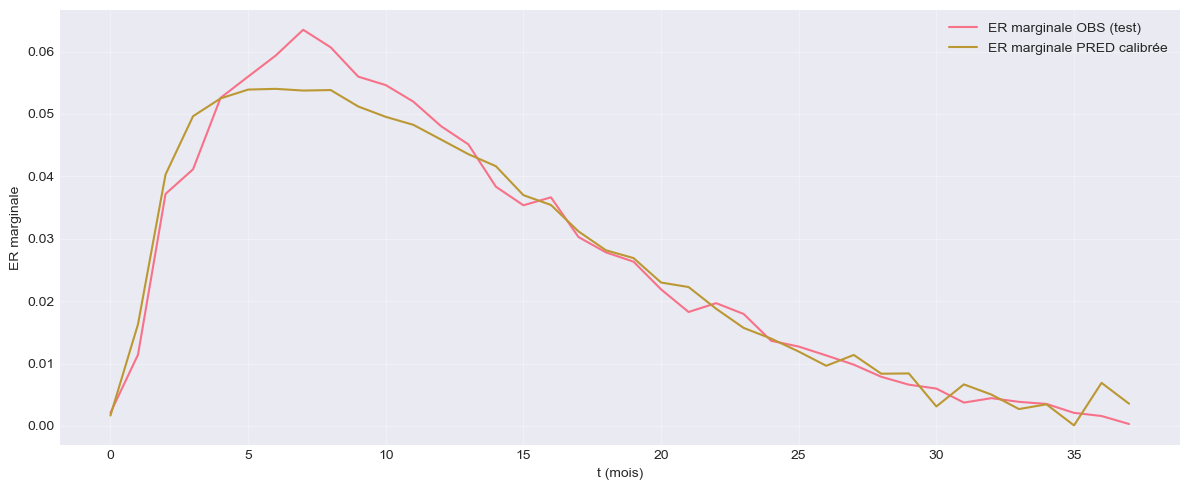

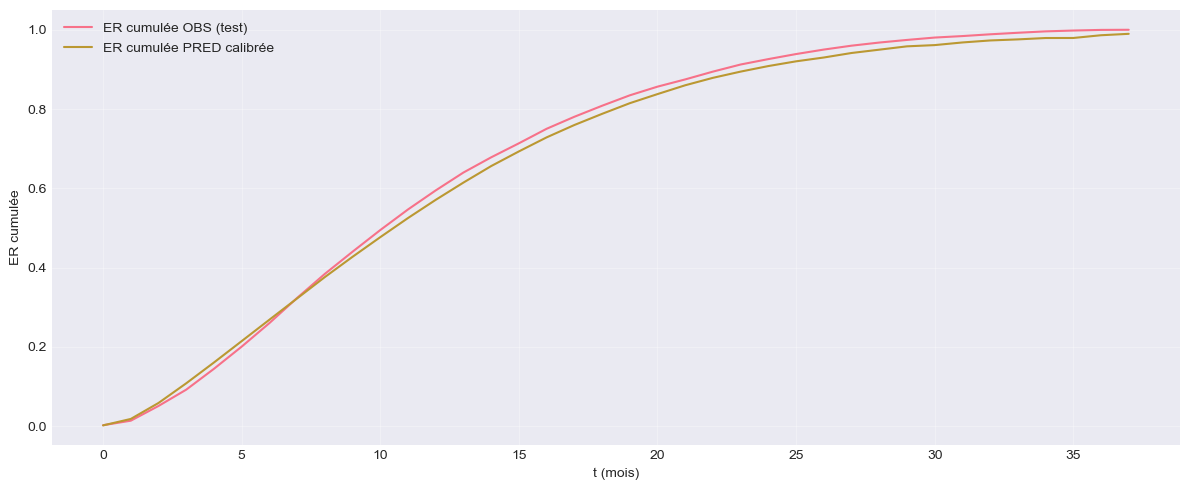

 t  ER_marginal_cal  ER_cumulee_cal
 0         0.001673        0.001673
 1         0.016298        0.017971
 2         0.040291        0.058262
 3         0.049638        0.107900
 4         0.052493        0.160393
 5         0.053906        0.214299
 6         0.054021        0.268320
 7         0.053750        0.322070
 8         0.053827        0.375897
 9         0.051197        0.427094


In [17]:
import matplotlib.pyplot as plt

# merge pour comparaison + plot
cmp_plot = haz_obs.merge(er_cal[["t","ER_marginal_cal","ER_cumulee_cal"]], on="t", how="inner")

# ---- Plot ER marginale ----
plt.figure(figsize=(12,5))
plt.plot(cmp_plot["t"], cmp_plot["ER_marginal_obs"], label="ER marginale OBS (test)")
plt.plot(cmp_plot["t"], cmp_plot["ER_marginal_cal"], label="ER marginale PRED calibrée")
plt.xlabel("t (mois)")
plt.ylabel("ER marginale")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot ER cumulée ----
plt.figure(figsize=(12,5))
plt.plot(cmp_plot["t"], cmp_plot["ER_cumulee_obs"], label="ER cumulée OBS (test)")
plt.plot(cmp_plot["t"], cmp_plot["ER_cumulee_cal"], label="ER cumulée PRED calibrée")
plt.xlabel("t (mois)")
plt.ylabel("ER cumulée")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Export table finale si besoin
er_final = er_cal[["t","ER_marginal_cal","ER_cumulee_cal"]].copy()
# er_final.to_csv("ER_pred_calibree.csv", index=False)
print(er_final.head(10).to_string(index=False))

In [20]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import patsy
from patsy import bs
from scipy.special import logit, expit

ID_COL = "ID"
DATE_COL = "Date_origination"

base = df_base.copy()
base[DATE_COL] = pd.to_datetime(base[DATE_COL], errors="coerce")

panel2 = panel.merge(
    base[[ID_COL, "Tx", "AGE_CLI", "produit", DATE_COL, "EVENT"]],
    on=ID_COL, how="left"
).dropna(subset=[DATE_COL, "Tx", "AGE_CLI", "produit"])

# produit2 (top15 global pour stabilité)
top_prod = panel2["produit"].value_counts().head(15).index
panel2["produit2"] = panel2["produit"].where(panel2["produit"].isin(top_prod), "Other")

# z-scores calculés sur TRAIN à chaque fold (on le fait dans la boucle)

formula = "y ~ bs(t, df=6, degree=3) + Tx_z + AGE_CLI_z + C(produit2)"

cuts = base[DATE_COL].quantile([0.6, 0.7, 0.8]).values  # 3 backtests

results = []

for k, cut in enumerate(cuts, 1):
    train_ids = set(base.loc[base[DATE_COL] <= cut, ID_COL])
    test_ids  = set(base.loc[base[DATE_COL] >  cut, ID_COL])

    train = panel2[panel2[ID_COL].isin(train_ids)].copy()
    test  = panel2[panel2[ID_COL].isin(test_ids)].copy()

    # standardisation sur train
    tx_mean, tx_std = train["Tx"].mean(), train["Tx"].std(ddof=0)
    age_mean, age_std = train["AGE_CLI"].mean(), train["AGE_CLI"].std(ddof=0)
    train["Tx_z"] = (train["Tx"]-tx_mean)/(tx_std if tx_std>0 else 1)
    test["Tx_z"]  = (test["Tx"]-tx_mean)/(tx_std if tx_std>0 else 1)
    train["AGE_CLI_z"] = (train["AGE_CLI"]-age_mean)/(age_std if age_std>0 else 1)
    test["AGE_CLI_z"]  = (test["AGE_CLI"]-age_mean)/(age_std if age_std>0 else 1)

    # fit
    y_tr, X_tr = patsy.dmatrices(formula, data=train, return_type="dataframe")
    res = sm.GLM(y_tr, X_tr, family=sm.families.Binomial()).fit()

    # predict hazard test
    _, X_te = patsy.dmatrices(formula, data=test.assign(y=0), return_type="dataframe")
    p0 = res.predict(X_te).clip(1e-9, 1-1e-9)

    # calibration delta sur le niveau (target = EVENT mean sur test en contrats)
    test_contracts = base[base[ID_COL].isin(test[ID_COL].unique())]
    target = test_contracts["EVENT"].mean()

    def ER_final_with_delta(delta):
        p = expit(logit(p0) + delta)
        tmp = pd.DataFrame({ID_COL: test[ID_COL].values, "t": test["t"].values, "p": p}).sort_values([ID_COL,"t"])
        tmp["S_i_t"] = tmp.groupby(ID_COL)["p"].apply(lambda s: (1 - s).cumprod()).reset_index(level=0, drop=True)
        S_port = tmp.groupby("t")["S_i_t"].mean()
        return 1 - S_port.iloc[-1]

    lo, hi = -10.0, 10.0
    for _ in range(30):
        mid = (lo+hi)/2
        if ER_final_with_delta(mid) < target: lo = mid
        else: hi = mid
    delta_star = (lo+hi)/2

    # courbe ER prédite calibrée
    p_cal = expit(logit(p0) + delta_star)
    tmp = pd.DataFrame({ID_COL: test[ID_COL].values, "t": test["t"].values, "p": p_cal}).sort_values([ID_COL,"t"])
    tmp["S_i_t"] = tmp.groupby(ID_COL)["p"].apply(lambda s: (1 - s).cumprod()).reset_index(level=0, drop=True)
    S_port = tmp.groupby("t", as_index=False).agg(S_t=("S_i_t","mean")).sort_values("t")
    S_port["ER_marg_pred"] = S_port["S_t"].shift(1).fillna(1.0) - S_port["S_t"]

    # courbe ER observée
    haz_obs = test.groupby("t", as_index=False).agg(N=("y","size"), E=("y","sum")).sort_values("t")
    haz_obs["h"] = haz_obs["E"]/haz_obs["N"]
    haz_obs["S_t"] = (1 - haz_obs["h"]).cumprod()
    haz_obs["ER_marg_obs"] = haz_obs["S_t"].shift(1).fillna(1.0) - haz_obs["S_t"]

    cmp = haz_obs.merge(S_port[["t","ER_marg_pred"]], on="t", how="inner")
    mae = (cmp["ER_marg_obs"] - cmp["ER_marg_pred"]).abs().mean()
    rmse = np.sqrt(((cmp["ER_marg_obs"] - cmp["ER_marg_pred"])**2).mean())

    results.append({"fold": k, "cut_date": pd.to_datetime(cut), "target_EVENT": float(target), "MAE": float(mae), "RMSE": float(rmse)})

pd.DataFrame(results)

,fold,cut_date,target_EVENT,MAE,RMSE
0,1,2019-07-11,0.989417,0.004919,0.006490
1,2,2020-02-07,0.989410,0.004139,0.005626
2,3,2020-11-04,0.989682,0.002614,0.003479


In [19]:
DATE_COL = "Date_origination"
max_t = int(panel["t"].max())  # normalement 60

dmin = pd.to_datetime(df_base[DATE_COL], errors="coerce").min()
dmax = pd.to_datetime(df_base[DATE_COL], errors="coerce").max()

start_needed = dmin.to_period("M").to_timestamp()
end_needed   = (dmax + pd.DateOffset(months=max_t)).to_period("M").to_timestamp()

print("Tu dois avoir Tx_marche de :", start_needed.date(), "à", end_needed.date())

Tu dois avoir Tx_marche de : 2006-01-01 à 2028-12-01
